In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('../../..'))
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from scripts import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [2]:
nodes = []
nodal_values = np.loadtxt('../../../text_files/nodes_minimal_model_.txt', delimiter=',')
for i in range(nodal_values.shape[0]):
  nodes.append(n.nodes(nodal_values[i, 0], nodal_values[i, 1], nodal_values[i, 2]))

# Material parameters

In [3]:
# Truss parameters
E = 210e9  # Young's modulus in Pascals
nu = 0.3   # Poisson's ratio
G = E / (2 * (1 + nu))  # Shear modulus in Pascals
m = 6.7504 * 10 ** 6 #kg
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq, h_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, h_truss, L_truss_element_y) 
L = 237.5
rho_truss = m / (L * Aeq)
It = (b_eq * h_eq**3 / 3) * (1 - 0.63 * (h_eq / b_eq) * (1 - (h_eq**4 / (12 * b_eq**4)))) *0.06
k = 0.08
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho_truss, Aeq, Ieqy, Ieqz, Ip]


k = 5/6
rho = 7850 #kg/m^3
E=210e9 #Pa
G = E/(2*(1+nu)) #Pa
nu = 0.3 #Poisson's ratio
k_fender = mat.stiffness_fenders()
Iy_connect, Iz_connect, Ip_connect, It_connect, A_connect = mat.stiffness_connecting_beams()
ep_K_connect = [E, G, A_connect, Iy_connect, Iz_connect, It_connect, k]
ep_m_connect = [rho, A_connect, Iy_connect, Iz_connect, Ip_connect]

t_eff = 1#m
A_eq_wall, I_eqy_wall, I_eqz_wall, b_eq_wall, rho_wall = mat.effective_retaining_wall_stiffness(t_eff)
Ip_wall = I_eqy_wall + I_eqz_wall
It_wall = (b_eq_wall * t_eff**3 / 3) * (1 - 0.63 * (b_eq_wall / t_eff) + 0.052 * (b_eq_wall / t_eff) **5)
ep_K_wall = [E, G, A_eq_wall, I_eqy_wall, I_eqz_wall, It_wall, k]
ep_m_wall = [rho_wall, A_eq_wall, I_eqy_wall, I_eqz_wall, Ip_wall]


# Sensitivity analysis

A sensitivity study is performed on the increase of the fender stiffness in the zdirection and the increase of rotational stiffness of the ball-joint in x, y and z direction.





In [4]:
elements = []
element_nodes = np.loadtxt('../../../text_files/element_nodes3.txt', dtype=int)

N = 200
k_fender_max = 3e8 #N/rad
k_fender_min = 100 #N/rad
kr_max = 1e13 #N/m

k_fender = np.arange(k_fender_min, k_fender_max, k_fender_max / N)
kr = np.arange(0, kr_max, kr_max / N)


# Sensitivity analysis run

In [5]:
param_space = np.zeros((N, N, 10)) # rows are kr and columns are Iy, layers are number of natural frequencies calculated
NN = len(nodes)
DOFS_per_node = 6
fender_dofs = [70, 75, 79, 83, 87, 91, 95, 99, 103, 107, 111, 115, 119, 123, 128]
dofs = n.degrees_of_freedom(nodes)
kr_dofs = [dofs['dof_1'][3], dofs['dof_1'][4], dofs['dof_1'][5]] 
k_fender_dofs = [dofs[f'dof_{kf+1}'][2] for kf in fender_dofs]



elements = []
element_nodes = np.loadtxt('../../../text_files/element_nodes3.txt', dtype=int)
for i in range(element_nodes.shape[0]):
    if element_nodes[i, 2] == 0:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K, ep_m))
    elif element_nodes[i, 2] == 1:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_wall, ep_m_wall))
    elif element_nodes[i, 2] == 2:
        elements.append(e.elements(nodes[element_nodes[i, 0] - 1], nodes[element_nodes[i, 1] - 1], ep_K_connect, ep_m_connect))

element_nodes = np.loadtxt('../../../text_files/element_nodes.txt', dtype=int)


dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))


for r in range(len(kr)):
    K_global = np.zeros((NN * DOFS_per_node, NN * DOFS_per_node))
    M_global = np.zeros((NN * DOFS_per_node, NN * DOFS_per_node))

    K_locs = []
    M_locs = []

    for elem in range(len(element_locs)):
        K_global[np.ix_(element_locs[elem], element_locs[elem])] += elements[elem][-1]
        M_global[np.ix_(element_locs[elem], element_locs[elem])] += elements[elem][-2]
    
    K_global = 0.5 * (K_global + K_global.T)
    M_global = 0.5 * (M_global + M_global.T)

    for dof in kr_dofs:
        K_global[dof, dof] += kr[r]

    for k in range(len(k_fender)):
        for dof in k_fender_dofs:
            K_global[dof, dof] += k_fender[k]

        indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_129'][0:2]))
        keep_indices = np.setdiff1d(np.arange(NN * DOFS_per_node), indices_to_remove)
        K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
        M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]
        eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)   

        tol = 1e-6
        positive = eigvals_global > tol
        eigvals_global = eigvals_global[positive]
        eigvecs_global = eigvecs_global[:, positive]

        frequencies_rad = np.sqrt(eigvals_global)
        frequencies_hz = frequencies_rad / (2 * np.pi)

        param_space[k, r, :] = frequencies_hz[:10]

        K_global = np.zeros((NN * DOFS_per_node, NN * DOFS_per_node))
        M_global = np.zeros((NN * DOFS_per_node, NN * DOFS_per_node))

        K_locs = []
        M_locs = []

        for elem in range(len(element_locs)):
            K_global[np.ix_(element_locs[elem], element_locs[elem])] += elements[elem][-1]
            M_global[np.ix_(element_locs[elem], element_locs[elem])] += elements[elem][-2]
        
        K_global = 0.5 * (K_global + K_global.T)
        M_global = 0.5 * (M_global + M_global.T)

    print(f'column {r +1} of {len(k_fender)} completed')

file_name = f'param_space_N{N}_kr0_{kr_max}_kf{int(k_fender_min)}_{int(k_fender_max)}.npy'
np.save(f'runs_kfender_kr/{file_name}', param_space)




column 1 of 200 completed
column 2 of 200 completed
column 3 of 200 completed
column 4 of 200 completed
column 5 of 200 completed
column 6 of 200 completed
column 7 of 200 completed
column 8 of 200 completed
column 9 of 200 completed
column 10 of 200 completed
column 11 of 200 completed
column 12 of 200 completed
column 13 of 200 completed
column 14 of 200 completed
column 15 of 200 completed
column 16 of 200 completed
column 17 of 200 completed
column 18 of 200 completed
column 19 of 200 completed
column 20 of 200 completed
column 21 of 200 completed
column 22 of 200 completed
column 23 of 200 completed
column 24 of 200 completed
column 25 of 200 completed
column 26 of 200 completed
column 27 of 200 completed
column 28 of 200 completed
column 29 of 200 completed
column 30 of 200 completed
column 31 of 200 completed
column 32 of 200 completed
column 33 of 200 completed
column 34 of 200 completed
column 35 of 200 completed
column 36 of 200 completed
column 37 of 200 completed
column 38 

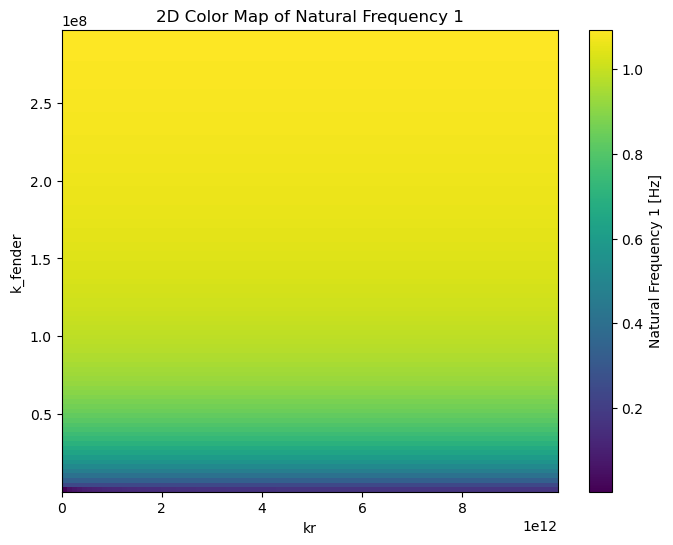

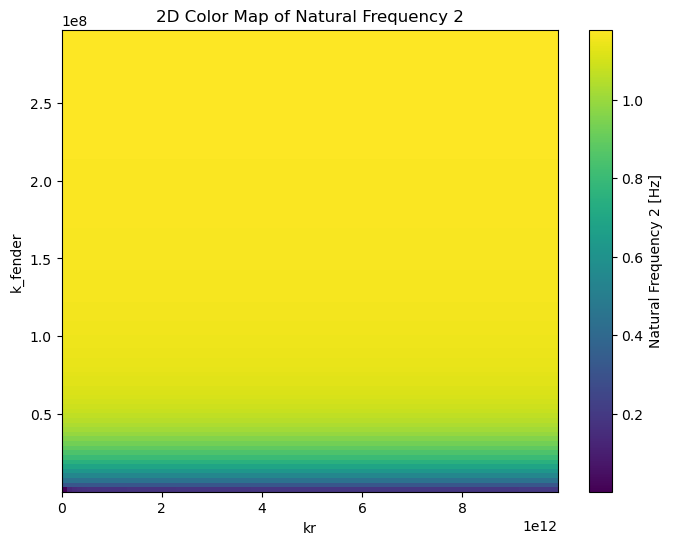

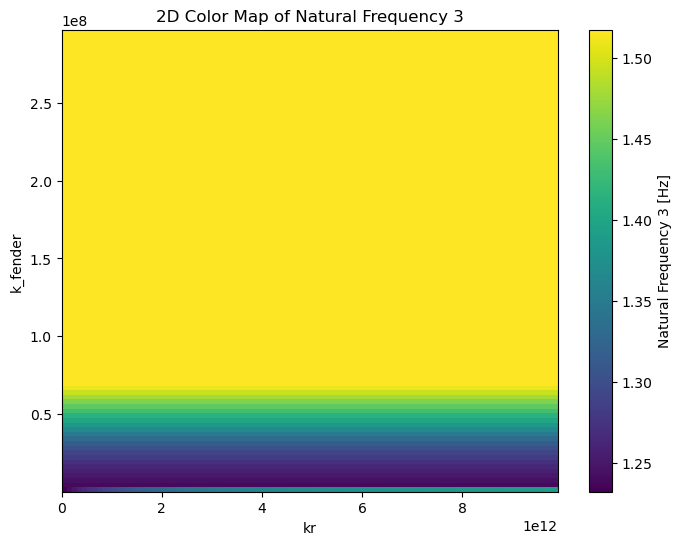

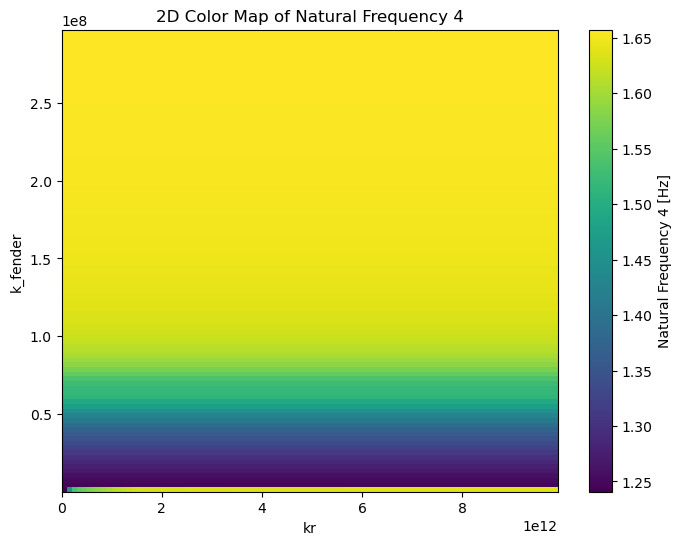

In [14]:
freqs_to_plot = 4  # Choose how many natural frequencies to plot
KF, KR = np.meshgrid(k_fender, kr, indexing='ij')

for freq_idx in range(min(freqs_to_plot, param_space.shape[2])):
    freq_data = param_space[:, :, freq_idx]
    
    # 2D Color Map
    plt.figure(figsize=(8, 6))
    plt.imshow(freq_data, origin='lower',
               extent=[kr.min(), kr.max(), k_fender.min(), k_fender.max()],
               aspect='auto')
    plt.colorbar(label=f"Natural Frequency {freq_idx + 1} [Hz]")
    plt.xlabel("kr")
    plt.ylabel("k_fender")
    plt.title(f"2D Color Map of Natural Frequency {freq_idx + 1}")
    plt.show()
    
    # 3D Surface Plot
    fig = go.Figure(data=[go.Surface(z=freq_data, x=KR, y=KF, colorscale='Viridis')])
    fig.update_layout(
        title=f'3D Surface of Natural Frequency {freq_idx + 1}',
        scene=dict(
            xaxis_title='kr',
            yaxis_title='k_fender',
            zaxis_title=f'Natural Frequency {freq_idx + 1} [Hz]'
        ),
        autosize=True
    )
    fig.show()
